# American option under regime-switching volatility

Same American put as example `03_american_option`, but volatility now
alternates between a **calm** and a **turbulent** regime governed by a
2-state continuous-time Markov chain (here discretised to per-period
transitions). Exercises `MarkovChain` as a built-in state primitive: the
user supplies the transition matrix and the solver advances the regime
state internally during backward induction.

## Problem

State: $(S_t, \tau_t)$ with $S_t$ the underlying price and $\tau_t \in
\{\mathrm{calm}, \mathrm{turbulent}\}$ the volatility regime.

- **Price dynamics** under each regime are risk-neutral GBM with regime-
  specific volatility:

  $$ S_{t+1} = S_t \, \exp\!\Bigl( (r - \tfrac12 \sigma_{\tau_t}^2)\,\Delta t + \sigma_{\tau_t}\,\sqrt{\Delta t}\, Z_{t+1} \Bigr). $$

- **Regime dynamics** are governed by the transition matrix $P$ with
  $P_{ij} = \Pr(\tau_{t+1} = j \mid \tau_t = i)$. With $P_{00} = 0.9$
  (calm tends to stay calm) and $P_{11} = 0.6$ (turbulent reverts faster
  to calm), the stationary distribution is $\pi = (0.8, 0.2)$ — calm
  80% of the time, turbulent 20%.

- **Action**: `DiscreteAction("exercise", n=2)` at each step.

- **Payoff**: $\max(K - S, 0)$ on exercise.

The Bellman recursion picks $\max(\mathrm{payoff}, \mathrm{continuation})$
as before, but **continuation value now depends on regime** — the
expectation over $S_{t+1}$ uses the regime's vol, AND the expectation
over $\tau_{t+1}$ uses the matrix row.

Headline result: optimal exercise boundary $S^*(t, \tau)$ depends on
regime. In the turbulent regime the option has more time value, so
the boundary is lower (hold longer); in the calm regime the boundary
is higher (exercise sooner since the option is unlikely to move much
further into the money).

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from bellgrid import (
    ContinuousState,
    DiscreteAction,
    MarkovChain,
    Problem,
    solve,
)
from bellgrid.grids import WarpedGrid
from bellgrid.shocks import Normal
from bellgrid.solvers import BackwardInduction

## Parameters

In [2]:
K_strike = 1.0
r = 0.05
T_years = 0.5
n_steps = 25
dt = T_years / n_steps
sigma_low = 0.15      # calm regime
sigma_high = 0.40     # turbulent regime
P = np.array([        # row-stochastic; stationary = (0.8, 0.2)
    [0.9, 0.1],
    [0.4, 0.6],
])
DEAD = -0.4
state_range = (-0.5, 3.0)
discount = math.exp(-r * dt)

# Stationary distribution (left eigenvector of P with eigenvalue 1)
vals, vecs = np.linalg.eig(P.T)
stationary = np.real(vecs[:, np.argmin(np.abs(vals - 1.0))])
stationary = stationary / stationary.sum()
sigma_avg = float(stationary @ np.array([sigma_low, sigma_high]))
print(f"Stationary distribution π = {stationary.round(4)}")
print(f"Long-run average σ = {sigma_avg:.4f}")

Stationary distribution π = [0.8 0.2]
Long-run average σ = 0.2000


## Bellgrid problem

- `ContinuousState("price")` with `asinh` warp and the absorbing-sentinel
  trick at $S = -0.4$ for "exercised" (same encoding as example 03).
- `MarkovChain("regime", matrix=P)` — the solver advances this state
  via the matrix; the user's `transition` callable must **not** return
  an entry for it.
- User's transition reads `state["regime"]` (long tensor of 0/1) and
  uses it to pick the right $\sigma$ via `torch.where`.

In [3]:
sigma_low_t = torch.tensor(sigma_low, dtype=torch.float64)
sigma_high_t = torch.tensor(sigma_high, dtype=torch.float64)


def payoff(S):
    return torch.where(
        S < 0,
        torch.zeros_like(S),
        torch.clamp(K_strike - S, min=0.0),
    )


def transition(state, action, shock, _t):
    S = state["price"]
    regime = state["regime"]
    sigma = torch.where(regime == 0, sigma_low_t, sigma_high_t)
    drift = (r - 0.5 * sigma**2) * dt
    diffusion = sigma * math.sqrt(dt)
    next_alive = S * torch.exp(drift + diffusion * shock["z"])
    is_alive = S >= 0
    not_exercised = action["exercise"] == 0
    dead = torch.full_like(S, DEAD)
    return {"price": torch.where(is_alive & not_exercised, next_alive, dead)}


def reward(state, action, _shock, _t):
    return action["exercise"].to(state["price"].dtype) * payoff(state["price"])


def terminal_reward(state):
    return payoff(state["price"])


problem = Problem(
    states=[
        ContinuousState("price", warp="asinh", range=state_range),
        MarkovChain("regime", matrix=P, labels=("calm", "turbulent")),
    ],
    actions=[DiscreteAction("exercise", n=2, labels=("hold", "exercise"))],
    transition=transition,
    reward=reward,
    shocks=[Normal("z", sigma=1.0)],
    horizon=range(0, n_steps),
    discount=discount,
    terminal_reward=terminal_reward,
)

policy, value = solve(
    problem,
    state_grid={"price": WarpedGrid(n=256)},
    action_grid={},
    solver=BackwardInduction(n_quad=11),
)

/home/tom_barrett/bellgrid/src/bellgrid/interpolation/multilinear.py:46: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  idx = torch.searchsorted(axis, query, right=False)


## Single-regime references (constant volatility)

Solve the same problem twice with a single Markov state collapsed to
the calm-σ and turbulent-σ values respectively (using the existing
constant-vol American put implementation). These bracket the regime-
switching solution: with no regime-switching, the option value would
be one of these. Also solve at the stationary-average σ — that's what
you'd get if you treated the long-run-average vol as a constant.

In [4]:
def solve_constant_vol(sigma_const):
    def _transition(state, action, shock, _t):
        S = state["price"]
        drift_c = (r - 0.5 * sigma_const**2) * dt
        diff_c = sigma_const * math.sqrt(dt)
        next_alive = S * torch.exp(drift_c + diff_c * shock["z"])
        is_alive = S >= 0
        not_exercised = action["exercise"] == 0
        dead = torch.full_like(S, DEAD)
        return {"price": torch.where(is_alive & not_exercised, next_alive, dead)}

    p = Problem(
        states=[ContinuousState("price", warp="asinh", range=state_range)],
        actions=[DiscreteAction("exercise", n=2, labels=("hold", "exercise"))],
        transition=_transition,
        reward=reward,
        shocks=[Normal("z", sigma=1.0)],
        horizon=range(0, n_steps),
        discount=discount,
        terminal_reward=terminal_reward,
    )
    pol, val = solve(
        p,
        state_grid={"price": WarpedGrid(n=256)},
        action_grid={},
        solver=BackwardInduction(n_quad=11),
    )
    return pol, val


policy_low, value_low = solve_constant_vol(sigma_low)
policy_high, value_high = solve_constant_vol(sigma_high)
policy_avg, value_avg = solve_constant_vol(sigma_avg)

## Value function vs spot, by regime

Two curves from bellgrid (one per starting regime), plus the three
constant-vol references. **The regime-switching curves do NOT match
the constant-vol-at-$\sigma_i$ curve for regime $i$** — even in the
calm regime, the option is more valuable than a constant-$\sigma_{\rm
low}$ option, because the agent factors in possible transitions to
the turbulent regime over the option's life.

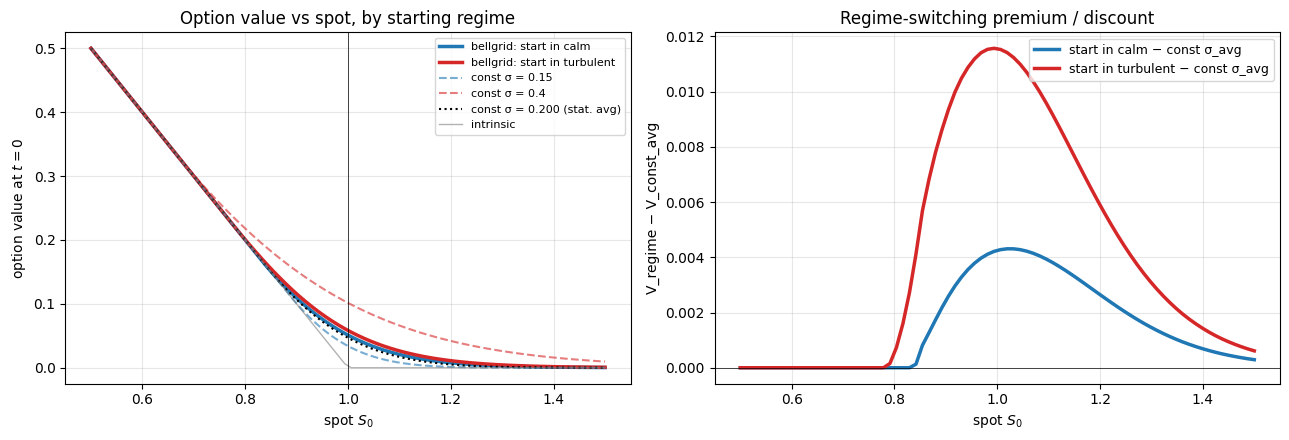

In [5]:
S_grid = np.linspace(0.5, 1.5, 80)
S_t = torch.tensor(S_grid, dtype=torch.float64)
v_calm = value(
    {"price": S_t, "regime": torch.zeros(80, dtype=torch.long)}, t=0
).numpy()
v_turb = value(
    {"price": S_t, "regime": torch.ones(80, dtype=torch.long)}, t=0
).numpy()
v_const_low = value_low({"price": S_t}, t=0).numpy()
v_const_high = value_high({"price": S_t}, t=0).numpy()
v_const_avg = value_avg({"price": S_t}, t=0).numpy()
intrinsic = np.maximum(K_strike - S_grid, 0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(S_grid, v_calm, lw=2.5, color="C0", label="bellgrid: start in calm")
ax1.plot(S_grid, v_turb, lw=2.5, color="C3", label="bellgrid: start in turbulent")
ax1.plot(S_grid, v_const_low, ls="--", lw=1.5, color="C0", alpha=0.6,
         label=f"const σ = {sigma_low}")
ax1.plot(S_grid, v_const_high, ls="--", lw=1.5, color="C3", alpha=0.6,
         label=f"const σ = {sigma_high}")
ax1.plot(S_grid, v_const_avg, ls=":", lw=1.5, color="black",
         label=f"const σ = {sigma_avg:.3f} (stat. avg)")
ax1.plot(S_grid, intrinsic, lw=1.0, color="gray", alpha=0.6,
         label="intrinsic")
ax1.axvline(K_strike, color="black", lw=0.5)
ax1.set_xlabel("spot $S_0$")
ax1.set_ylabel("option value at $t=0$")
ax1.set_title("Option value vs spot, by starting regime")
ax1.legend(fontsize=8, loc="upper right")
ax1.grid(alpha=0.3)

# Difference: regime-switching value minus const-stationary-avg value
ax2.plot(S_grid, v_calm - v_const_avg, lw=2.5, color="C0",
         label="start in calm − const σ_avg")
ax2.plot(S_grid, v_turb - v_const_avg, lw=2.5, color="C3",
         label="start in turbulent − const σ_avg")
ax2.axhline(0.0, color="black", lw=0.5)
ax2.set_xlabel("spot $S_0$")
ax2.set_ylabel("V_regime − V_const_avg")
ax2.set_title("Regime-switching premium / discount")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Optimal exercise boundary across time, by regime

Sweep over $t = 0, \ldots, T-1$ and find the highest spot at which
the optimal action is "exercise" in each regime. The boundary in
the calm regime sits **above** the boundary in the turbulent regime
— when vol is low you exercise sooner, because there's little upside
to waiting; when vol is high you hold even quite-deep-ITM positions
because their continuation value is still meaningful.

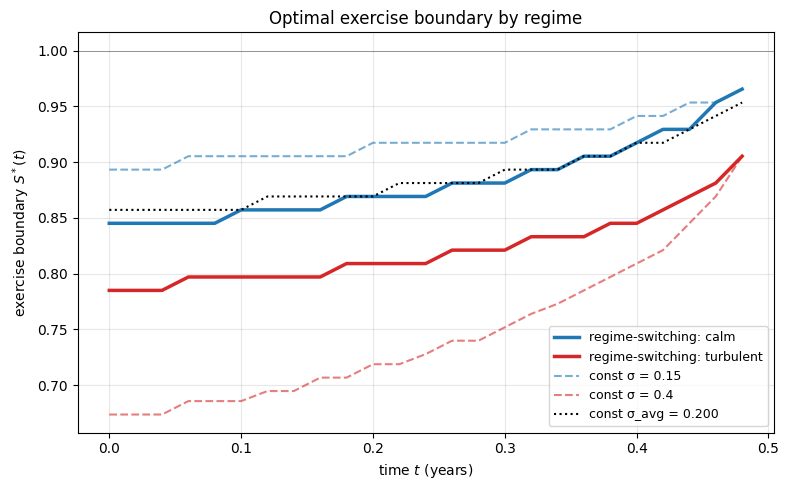

In [6]:
S_search = np.linspace(0.0, K_strike * 1.2, 400)
S_search_t = torch.tensor(S_search, dtype=torch.float64)

boundary_calm = []
boundary_turb = []
boundary_const_low = []
boundary_const_high = []
boundary_const_avg = []
for t in range(n_steps):
    a_calm = policy(
        {"price": S_search_t, "regime": torch.zeros(400, dtype=torch.long)}, t=t
    )["exercise"].numpy()
    a_turb = policy(
        {"price": S_search_t, "regime": torch.ones(400, dtype=torch.long)}, t=t
    )["exercise"].numpy()
    a_low = policy_low({"price": S_search_t}, t=t)["exercise"].numpy()
    a_high = policy_high({"price": S_search_t}, t=t)["exercise"].numpy()
    a_avg = policy_avg({"price": S_search_t}, t=t)["exercise"].numpy()

    def _largest_exercise(arr):
        idx = np.where(arr == 1)[0]
        return S_search[idx[-1]] if len(idx) > 0 else 0.0

    boundary_calm.append(_largest_exercise(a_calm))
    boundary_turb.append(_largest_exercise(a_turb))
    boundary_const_low.append(_largest_exercise(a_low))
    boundary_const_high.append(_largest_exercise(a_high))
    boundary_const_avg.append(_largest_exercise(a_avg))

t_axis = np.arange(n_steps) * dt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_axis, boundary_calm, lw=2.5, color="C0", label="regime-switching: calm")
ax.plot(t_axis, boundary_turb, lw=2.5, color="C3", label="regime-switching: turbulent")
ax.plot(t_axis, boundary_const_low, ls="--", lw=1.5, color="C0", alpha=0.6,
        label=f"const σ = {sigma_low}")
ax.plot(t_axis, boundary_const_high, ls="--", lw=1.5, color="C3", alpha=0.6,
        label=f"const σ = {sigma_high}")
ax.plot(t_axis, boundary_const_avg, ls=":", lw=1.5, color="black",
        label=f"const σ_avg = {sigma_avg:.3f}")
ax.axhline(K_strike, color="black", lw=0.5, alpha=0.5)
ax.set_xlabel("time $t$ (years)")
ax.set_ylabel("exercise boundary $S^*(t)$")
ax.set_title("Optimal exercise boundary by regime")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Detailed table: option values at expiry-like moneyness

Bellgrid value (per regime) vs constant-vol references, across a sweep
of moneyness. The regime-switching values sit strictly between the
two constant-vol bounds and **shift toward** the bound matching the
starting regime — but not all the way, since the option's life will
see regime transitions.

In [7]:
spot_table = [0.7, 0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2]
print(f"{'S0':>6} {'V_calm':>10} {'V_turb':>10} {'V_σ_low':>10}"
      f" {'V_σ_avg':>10} {'V_σ_high':>10}")
print("-" * 64)
for S0 in spot_table:
    s = torch.tensor([S0], dtype=torch.float64)
    r_calm = value({"price": s, "regime": torch.tensor([0], dtype=torch.long)}, t=0).item()
    r_turb = value({"price": s, "regime": torch.tensor([1], dtype=torch.long)}, t=0).item()
    r_low = value_low({"price": s}, t=0).item()
    r_avg = value_avg({"price": s}, t=0).item()
    r_high = value_high({"price": s}, t=0).item()
    print(f"{S0:>6.2f} {r_calm:>10.5f} {r_turb:>10.5f} {r_low:>10.5f}"
          f" {r_avg:>10.5f} {r_high:>10.5f}")

    S0     V_calm     V_turb    V_σ_low    V_σ_avg   V_σ_high
----------------------------------------------------------------
  0.70    0.29999    0.29999    0.29999    0.29999    0.30180
  0.80    0.19999    0.20053    0.19999    0.19999    0.21802
  0.90    0.10910    0.11574    0.10027    0.10667    0.15142
  0.95    0.07608    0.08345    0.06100    0.07239    0.12450
  1.00    0.05104    0.05835    0.03396    0.04679    0.10154
  1.05    0.03307    0.03969    0.01723    0.02881    0.08220
  1.10    0.02086    0.02640    0.00800    0.01697    0.06611
  1.20    0.00779    0.01103    0.00131    0.00514    0.04195
